# CV Notebook

Kaggle-safe CV classification template:

```text
RAW IMAGE -> SEGMENT/CROP at original resolution -> PREPROCESS/RESIZE
-> AUGMENT -> CNN FROM SCRATCH -> VALIDATE -> SUBMIT
```

No widgets. No pretrained model. Use the parameter cell above each machine cell.

**First thing:** read the Kaggle metric. Set `EVAL_BLOCK` and `LOSS_BLOCK` accordingly.

In [16]:
# ============================================================
# 0. GLOBAL SETUP
# ============================================================

print("BACA METRIC KAGGLE DULU. Then set EVAL_BLOCK / LOSS_BLOCK in Step 7.")

import os
import re
import gc
import time
import copy
import math
import json
import random
import hashlib
import warnings
from pathlib import Path
from collections import defaultdict

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageOps, ImageEnhance, UnidentifiedImageError

try:
    import cv2
    CV2_AVAILABLE = True
except Exception as e:
    cv2 = None
    CV2_AVAILABLE = False
    print("cv2 unavailable. OpenCV blocks will use PIL/NumPy fallback where possible:", repr(e))

try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    from torch.utils.data import Dataset, DataLoader
    TORCH_AVAILABLE = True
except Exception as e:
    torch = None
    nn = None
    F = None
    Dataset = object
    DataLoader = None
    TORCH_AVAILABLE = False
    print("PyTorch unavailable. Training cells require Kaggle/PyTorch runtime:", repr(e))

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score, confusion_matrix

try:
    from IPython.display import display
except Exception:
    def display(x):
        print(x)

SEED = 42
FAST_DEBUG = True  # set False for serious runs

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    if TORCH_AVAILABLE:
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.benchmark = True

seed_everything(SEED)

DEVICE = "cuda" if TORCH_AVAILABLE and torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

STATE = {
    "train_df": None,
    "test_df": None,
    "sample_submission": None,
    "label_encoder": None,
    "num_classes": None,
    "num_channels": None,
    "data_cache": {},
    "model": None,
    "best_model": None,
    "best_score": None,
    "best_run": None,
    "best_config": None,
    "runs": [],
    "health": {},
}

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

def step(msg):
    print("\n" + "=" * 100)
    print(msg)
    print("=" * 100)

def show_grid(images, titles=None, n=16, figsize=(12, 12), cmap=None):
    images = list(images)[:n]
    if len(images) == 0:
        print("No images to show.")
        return
    cols = min(4, len(images))
    rows = math.ceil(len(images) / cols)
    plt.figure(figsize=figsize)
    for i, img in enumerate(images):
        plt.subplot(rows, cols, i + 1)
        arr = np.asarray(img)
        if arr.ndim == 2:
            plt.imshow(arr, cmap=cmap or "gray")
        else:
            plt.imshow(arr)
        if titles is not None:
            plt.title(str(titles[i])[:60], fontsize=9)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

def describe_options(title, options):
    print("\n" + title)
    for name, desc in options.items():
        print(f"- {name}: {desc}")

BACA METRIC KAGGLE DULU. Then set EVAL_BLOCK / LOSS_BLOCK in Step 7.
DEVICE: cuda


## Recipe Suggestions

Recipes are suggestions only. Copy their values into the parameter cells when useful.

In [17]:
import os
DATA_ROOT = "/kaggle/input/competitions/seleksi-gemastik-2026-problem-2/data"
files = sorted(os.listdir(f"{DATA_ROOT}/images"))[:5]
print(files)  # liat: id_0001.png? id_1.png?
import pandas as pd
print(pd.read_csv(f"{DATA_ROOT}/train.csv").head())
print(pd.read_csv(f"{DATA_ROOT}/sample_submission.csv").head())

['id_000D.png', 'id_00CR.png', 'id_00H2.png', 'id_00LN.png', 'id_00N1.png']
  image_id  char
0  id_30U7  9610
1  id_5OK6  9041
2  id_EKC8  4202
3  id_GYIW  3201
4  id_213Y  1602
  image_id image_pair
0  id_DCBL    id_AAAA
1  id_YUKN    id_AAAA
2  id_25WM    id_AAAA
3  id_6ESM    id_AAAA
4  id_L51F    id_AAAA


In [18]:
RECIPES = {
    "fast_debug": {
        "SEGMENT_BLOCK": "none",
        "PREPROCESS_BLOCK": "resize_pad_rgb",
        "AUGMENT_BLOCK": "no_aug",
        "MODEL_BLOCK": "tiny_cnn",
        "IMG_SIZE": 96,
        "EPOCHS": 2,
    },
    "safe_baseline": {
        "SEGMENT_BLOCK": "none",
        "PREPROCESS_BLOCK": "resize_pad_rgb",
        "AUGMENT_BLOCK": "light_aug",
        "MODEL_BLOCK": "small_cnn",
    },
    "object_crop": {
        "SEGMENT_BLOCK": "contour_crop",
        "PREPROCESS_BLOCK": "resize_pad_rgb",
        "AUGMENT_BLOCK": "light_aug",
        "MODEL_BLOCK": "small_cnn",
    },
    "document_symbol": {
        "SEGMENT_BLOCK": "threshold_crop",
        "PREPROCESS_BLOCK": "clahe_gray",
        "AUGMENT_BLOCK": "safe_document_aug",
        "MODEL_BLOCK": "small_cnn",
    },
    "big_image_spread": {
        "SEGMENT_BLOCK": "tile_3x3",
        "TILE_AGG": "mean_softmax",
        "PREPROCESS_BLOCK": "resize_pad_rgb",
        "AUGMENT_BLOCK": "light_aug",
        "MODEL_BLOCK": "small_cnn",
    },
    "strong_after_submit": {
        "AUGMENT_BLOCK": "medium_aug",
        "MODEL_BLOCK": "residual_small",
        "EPOCHS": 25,
    },
}

def show_recipe(name="safe_baseline"):
    step(f"Recipe suggestion: {name}")
    if name not in RECIPES:
        print("Unknown recipe. Available:", list(RECIPES))
        return
    for k, v in RECIPES[name].items():
        print(f"{k} = {repr(v)}")

show_recipe("safe_baseline")
print("\nTiling warning: tile modes inherit original image labels. Use only if the class signal is spread across the image.")


Recipe suggestion: safe_baseline
SEGMENT_BLOCK = 'none'
PREPROCESS_BLOCK = 'resize_pad_rgb'
AUGMENT_BLOCK = 'light_aug'
MODEL_BLOCK = 'small_cnn'

Tiling warning: tile modes inherit original image labels. Use only if the class signal is spread across the image.


## 1A. Parameter: Loader Manual

In [19]:
# ============================================================
# 1A. LOADER PARAMETERS
# ============================================================

LOADER_MODE = "csv_path"  # "folder_class" / "csv_path" / "csv_pixels"

DATA_ROOT = "/kaggle/input/competitions/seleksi-gemastik-2026-problem-2/data"

# Common paths. Leave CSV paths None to auto-find train/test/sample by filename.
TRAIN_CSV = f"{DATA_ROOT}/train.csv"
TEST_CSV = f"{DATA_ROOT}/sample_submission.csv"
SAMPLE_SUBMISSION_CSV = f"{DATA_ROOT}/sample_submission.csv"

# csv_path mode.
IMAGE_COL = "image_id"
LABEL_COL = "char"
ID_COL = "image_id"
IMAGE_ROOT = f"{DATA_ROOT}/images"

# folder_class mode.
TRAIN_DIR = None
TEST_DIR = None

# csv_pixels mode.
PIXEL_COLS = None       # list of pixel columns, or None to use numeric columns except label/id
PIXEL_PREFIX = None    # e.g. "pixel"; used only if PIXEL_COLS is None
PIXEL_SHAPE = (28, 28, 1)      # e.g. (28, 28, 1). Must be set for csv_pixels.

PREVIEW_ROWS = 16

In [20]:
# Reset state biar gak ke-cache yang lama
_IMAGE_INDEX = None
STATE["data_cache"] = {}
STATE["train_df"] = None
STATE["test_df"] = None

load_dataset()

# Verify
print(STATE["train_df"].columns.tolist())
assert "_label_encoded" in STATE["train_df"].columns, "Step 1B incomplete!"


Step 1/9: Loading data
TRAIN_CSV: /kaggle/input/competitions/seleksi-gemastik-2026-problem-2/data/train.csv
TEST_CSV : /kaggle/input/competitions/seleksi-gemastik-2026-problem-2/data/sample_submission.csv
SAMPLE   : /kaggle/input/competitions/seleksi-gemastik-2026-problem-2/data/sample_submission.csv
train/test/sample shapes: (500, 2) (500, 2) (500, 2)
Candidate ID columns   : ['image_id']
Candidate image columns: []
Candidate label columns: ['char']
LOADER_MODE: csv_path
num_classes: 500
classes: ['1011', '1016', '1045', '1061', '110', '1128', '114', '1141', '1168', '1216', '122', '1231', '1276', '1303', '131', '1345', '1387', '1390', '1404', '1405', '1408', '144', '1482', '1510', '1529', '1567', '1571', '1581', '1602', '1639'] ...

Train preview:


,image_id,char,_image_path,_label,_id,_orig_index,_label_encoded
0,id_30U7,9610,/kaggle/input/competitions/seleksi-gemastik-20...,9610,id_30U7,0,483
1,id_5OK6,9041,/kaggle/input/competitions/seleksi-gemastik-20...,9041,id_5OK6,1,452
2,id_EKC8,4202,/kaggle/input/competitions/seleksi-gemastik-20...,4202,id_EKC8,2,182



Test preview:


,image_id,image_pair,_image_path,_label,_id,_orig_index,_label_encoded
0,id_DCBL,id_AAAA,/kaggle/input/competitions/seleksi-gemastik-20...,__unknown__,id_DCBL,0,-1
1,id_YUKN,id_AAAA,/kaggle/input/competitions/seleksi-gemastik-20...,__unknown__,id_YUKN,1,-1
2,id_25WM,id_AAAA,/kaggle/input/competitions/seleksi-gemastik-20...,__unknown__,id_25WM,2,-1



Sample submission preview:


,image_id,image_pair
0,id_DCBL,id_AAAA
1,id_YUKN,id_AAAA
2,id_25WM,id_AAAA


['image_id', 'char', '_image_path', '_label', '_id', '_orig_index', '_label_encoded']


In [21]:
print(STATE["train_df"].columns.tolist())
print(STATE["train_df"].head(2))

['image_id', 'char', '_image_path', '_label', '_id', '_orig_index', '_label_encoded']
  image_id  char                                        _image_path _label  \
0  id_30U7  9610  /kaggle/input/competitions/seleksi-gemastik-20...   9610   
1  id_5OK6  9041  /kaggle/input/competitions/seleksi-gemastik-20...   9041   

       _id  _orig_index  _label_encoded  
0  id_30U7            0             483  
1  id_5OK6            1             452  


In [22]:
import traceback
try:
    load_dataset()
except Exception:
    traceback.print_exc()


Step 1/9: Loading data
TRAIN_CSV: /kaggle/input/competitions/seleksi-gemastik-2026-problem-2/data/train.csv
TEST_CSV : /kaggle/input/competitions/seleksi-gemastik-2026-problem-2/data/sample_submission.csv
SAMPLE   : /kaggle/input/competitions/seleksi-gemastik-2026-problem-2/data/sample_submission.csv
train/test/sample shapes: (500, 2) (500, 2) (500, 2)
Candidate ID columns   : ['image_id']
Candidate image columns: []
Candidate label columns: ['char']
LOADER_MODE: csv_path
num_classes: 500
classes: ['1011', '1016', '1045', '1061', '110', '1128', '114', '1141', '1168', '1216', '122', '1231', '1276', '1303', '131', '1345', '1387', '1390', '1404', '1405', '1408', '144', '1482', '1510', '1529', '1567', '1571', '1581', '1602', '1639'] ...

Train preview:


,image_id,char,_image_path,_label,_id,_orig_index,_label_encoded
0,id_30U7,9610,/kaggle/input/competitions/seleksi-gemastik-20...,9610,id_30U7,0,483
1,id_5OK6,9041,/kaggle/input/competitions/seleksi-gemastik-20...,9041,id_5OK6,1,452
2,id_EKC8,4202,/kaggle/input/competitions/seleksi-gemastik-20...,4202,id_EKC8,2,182



Test preview:


,image_id,image_pair,_image_path,_label,_id,_orig_index,_label_encoded
0,id_DCBL,id_AAAA,/kaggle/input/competitions/seleksi-gemastik-20...,__unknown__,id_DCBL,0,-1
1,id_YUKN,id_AAAA,/kaggle/input/competitions/seleksi-gemastik-20...,__unknown__,id_YUKN,1,-1
2,id_25WM,id_AAAA,/kaggle/input/competitions/seleksi-gemastik-20...,__unknown__,id_25WM,2,-1



Sample submission preview:


,image_id,image_pair
0,id_DCBL,id_AAAA
1,id_YUKN,id_AAAA
2,id_25WM,id_AAAA


## 1B. Mesin: Load Data

In [23]:
# ============================================================
# 1B. LOAD DATA MACHINE
# ============================================================

IMAGE_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".gif", ".tif", ".tiff", ".webp"}

def input_roots():
    roots = []
    if Path("/kaggle/input").exists():
        roots.append(Path("/kaggle/input"))
    roots.append(Path("."))
    return roots

def find_named_csv(keyword):
    candidates = []
    for root in input_roots():
        candidates.extend(root.glob(f"**/*{keyword}*.csv"))
    candidates = sorted(set(candidates), key=lambda p: len(str(p)))
    return candidates[0] if candidates else None

def list_image_dirs(limit=25):
    dirs = []
    for root in input_roots():
        for p in root.glob("**/*"):
            if p.is_dir():
                try:
                    has_img = any(child.is_file() and child.suffix.lower() in IMAGE_EXTS for child in p.iterdir())
                    if has_img:
                        dirs.append(p)
                except Exception:
                    pass
    return dirs[:limit]

def column_candidates(df):
    cols = list(df.columns)
    id_cands = [c for c in cols if str(c).lower() in ["id","image_id","imageid","file_id","filename","file","path","image"] or "id" in str(c).lower()]
    path_cands = []
    for c in cols:
        s = df[c].dropna().astype(str).head(80)
        if len(s) and s.map(lambda x: Path(x).suffix.lower() in IMAGE_EXTS or "/" in x or "\\" in x).mean() > 0.3:
            path_cands.append(c)
    label_cands = [c for c in cols if str(c).lower() in ["label","target","class","category","species","char","y"]]
    pixel_cands = [c for c in cols if str(c).lower().startswith("pixel")]
    return id_cands, path_cands, label_cands, pixel_cands

# ---- Gemastik-style resolver: image_id (e.g. "30U7") -> id_30U7.png ----
ID_EXT = ".png"

def resolve_path(x, root=None):
    if pd.isna(x):
        return None
    s = str(x).strip()
    # build expected filename
    if s.lower().endswith(ID_EXT):
        fname = s
    elif s.startswith("id_"):
        fname = s if "." in s else s + ID_EXT
    else:
        fname = f"id_{s}{ID_EXT}"
    base = root or IMAGE_ROOT
    if base:
        return str(Path(base) / fname)
    # fallback: search input roots
    for b in input_roots():
        rp = b / fname
        if rp.exists():
            return str(rp)
    return fname

def read_image_rgb(path):
    try:
        img = Image.open(path).convert("RGB")
        return np.asarray(img)
    except Exception as e:
        raise RuntimeError(f"Could not read image: {path} | {repr(e)}")

def pixels_to_image(row, pixel_cols, shape):
    arr = row[pixel_cols].to_numpy(dtype=np.float32).reshape(shape)
    if arr.max() <= 1.0:
        arr = arr * 255.0
    arr = np.clip(arr, 0, 255).astype(np.uint8)
    if arr.ndim == 2:
        arr = np.stack([arr, arr, arr], axis=-1)
    elif arr.shape[-1] == 1:
        arr = np.repeat(arr, 3, axis=-1)
    return arr

def load_csvs():
    train_csv = Path(TRAIN_CSV) if TRAIN_CSV else find_named_csv("train")
    test_csv = Path(TEST_CSV) if TEST_CSV else find_named_csv("test")
    sample_csv = Path(SAMPLE_SUBMISSION_CSV) if SAMPLE_SUBMISSION_CSV else find_named_csv("sample")
    if train_csv is None or test_csv is None:
        raise FileNotFoundError("Could not find train/test csv. Set TRAIN_CSV and TEST_CSV manually.")
    train_df = pd.read_csv(train_csv)
    test_df = pd.read_csv(test_csv)
    sample = pd.read_csv(sample_csv) if sample_csv is not None else None
    print("TRAIN_CSV:", train_csv)
    print("TEST_CSV :", test_csv)
    print("SAMPLE   :", sample_csv)
    print("train/test/sample shapes:", train_df.shape, test_df.shape, None if sample is None else sample.shape)
    return train_df, test_df, sample

def infer_test_ids(test_df, sample):
    if ID_COL and ID_COL in test_df.columns:
        return test_df[ID_COL]
    if sample is not None and len(sample) == len(test_df):
        return sample.iloc[:, 0].values
    return np.arange(len(test_df))

def load_dataset():
    step("Step 1/9: Loading data")
    mode = LOADER_MODE
    sample = None

    if mode == "csv_path":
        train_df, test_df, sample = load_csvs()
        id_cands, path_cands, label_cands, pixel_cands = column_candidates(train_df)
        print("Candidate ID columns   :", id_cands)
        print("Candidate image columns:", path_cands)
        print("Candidate label columns:", label_cands)
        if IMAGE_COL is None or LABEL_COL is None:
            raise ValueError("Set IMAGE_COL and LABEL_COL manually in Step 1A.")
        train_df = train_df.copy()
        test_df = test_df.copy()
        train_df["_image_path"] = train_df[IMAGE_COL].map(lambda x: resolve_path(x, IMAGE_ROOT))
        test_df["_image_path"] = test_df[IMAGE_COL].map(lambda x: resolve_path(x, IMAGE_ROOT))
        train_df["_label"] = train_df[LABEL_COL].astype(str)
        # test_df might not have LABEL_COL (e.g. sample_submission); fill placeholder
        if LABEL_COL in test_df.columns:
            test_df["_label"] = test_df[LABEL_COL].astype(str)
        else:
            test_df["_label"] = "__unknown__"
        train_df["_id"] = train_df[ID_COL] if ID_COL and ID_COL in train_df.columns else np.arange(len(train_df))
        test_df["_id"] = infer_test_ids(test_df, sample)
        train_df["_orig_index"] = np.arange(len(train_df))
        test_df["_orig_index"] = np.arange(len(test_df))

    elif mode == "folder_class":
        sample_csv = Path(SAMPLE_SUBMISSION_CSV) if SAMPLE_SUBMISSION_CSV else find_named_csv("sample")
        sample = pd.read_csv(sample_csv) if sample_csv is not None else None
        if TRAIN_DIR is None or TEST_DIR is None:
            print("Image folders found:")
            for d in list_image_dirs():
                print("-", d)
            raise ValueError("Set TRAIN_DIR and TEST_DIR manually in Step 1A.")
        rows = []
        for class_dir in sorted(Path(TRAIN_DIR).iterdir()):
            if class_dir.is_dir():
                for p in sorted(class_dir.rglob("*")):
                    if p.suffix.lower() in IMAGE_EXTS:
                        rows.append({"_image_path": str(p), "_label": class_dir.name, "_id": p.stem})
        train_df = pd.DataFrame(rows)
        test_rows = [{"_image_path": str(p), "_id": p.stem} for p in sorted(Path(TEST_DIR).rglob("*")) if p.suffix.lower() in IMAGE_EXTS]
        test_df = pd.DataFrame(test_rows)
        test_df["_label"] = "__unknown__"
        train_df["_orig_index"] = np.arange(len(train_df))
        test_df["_orig_index"] = np.arange(len(test_df))

    elif mode == "csv_pixels":
        train_df, test_df, sample = load_csvs()
        if PIXEL_COLS is not None:
            pixel_cols = list(PIXEL_COLS)
        elif PIXEL_PREFIX is not None:
            pixel_cols = [c for c in train_df.columns if str(c).startswith(PIXEL_PREFIX)]
        else:
            skip = {LABEL_COL}
            if ID_COL: skip.add(ID_COL)
            pixel_cols = [c for c in train_df.columns if c not in skip and pd.api.types.is_numeric_dtype(train_df[c])]
        if not pixel_cols:
            raise ValueError("No pixel columns found.")
        train_df = train_df.copy(); test_df = test_df.copy()
        train_df["_pixel_cols"] = [pixel_cols] * len(train_df)
        test_df["_pixel_cols"] = [pixel_cols] * len(test_df)
        train_df["_label"] = train_df[LABEL_COL].astype(str)
        test_df["_label"] = test_df[LABEL_COL].astype(str) if LABEL_COL in test_df.columns else "__unknown__"
        train_df["_id"] = train_df[ID_COL] if ID_COL and ID_COL in train_df.columns else np.arange(len(train_df))
        test_df["_id"] = infer_test_ids(test_df, sample)
        train_df["_orig_index"] = np.arange(len(train_df))
        test_df["_orig_index"] = np.arange(len(test_df))
    else:
        raise ValueError(f"Unknown LOADER_MODE: {mode}")

    # ====== LABEL ENCODING (yang sebelumnya hilang) ======
    le = LabelEncoder()
    train_df["_label_encoded"] = le.fit_transform(train_df["_label"].astype(str))
    # test_df: encode kalau labelnya valid, else -1 placeholder
    def _safe_encode(v):
        try:
            return int(le.transform([str(v)])[0])
        except Exception:
            return -1
    test_df["_label_encoded"] = test_df["_label"].map(_safe_encode)

    classes = list(le.classes_)
    label_counts = train_df["_label"].astype(str).value_counts()

    STATE["train_df"] = train_df.reset_index(drop=True)
    STATE["test_df"] = test_df.reset_index(drop=True)
    STATE["sample_submission"] = sample
    STATE["label_encoder"] = le
    STATE["classes"] = classes
    STATE["num_classes"] = len(classes)
    STATE["label_counts"] = label_counts
    STATE["data_cache"] = {}   # invalidate cache lama

    print("LOADER_MODE:", LOADER_MODE)
    print("num_classes:", STATE["num_classes"])
    print("classes:", classes[:30], "..." if len(classes) > 30 else "")
    print("\nTrain preview:")
    display(STATE["train_df"].head(3))
    print("\nTest preview:")
    display(STATE["test_df"].head(3))
    if sample is not None:
        print("\nSample submission preview:")
        display(sample.head(3))

def get_raw_image(df, idx):
    row = df.iloc[idx]
    if LOADER_MODE == "csv_pixels":
        return pixels_to_image(row, row["_pixel_cols"], PIXEL_SHAPE)
    return read_image_rgb(row["_image_path"])

# Reset cache + state biar fresh
_IMAGE_INDEX = None
load_dataset()


Step 1/9: Loading data
TRAIN_CSV: /kaggle/input/competitions/seleksi-gemastik-2026-problem-2/data/train.csv
TEST_CSV : /kaggle/input/competitions/seleksi-gemastik-2026-problem-2/data/sample_submission.csv
SAMPLE   : /kaggle/input/competitions/seleksi-gemastik-2026-problem-2/data/sample_submission.csv
train/test/sample shapes: (500, 2) (500, 2) (500, 2)
Candidate ID columns   : ['image_id']
Candidate image columns: []
Candidate label columns: ['char']
LOADER_MODE: csv_path
num_classes: 500
classes: ['1011', '1016', '1045', '1061', '110', '1128', '114', '1141', '1168', '1216', '122', '1231', '1276', '1303', '131', '1345', '1387', '1390', '1404', '1405', '1408', '144', '1482', '1510', '1529', '1567', '1571', '1581', '1602', '1639'] ...

Train preview:


,image_id,char,_image_path,_label,_id,_orig_index,_label_encoded
0,id_30U7,9610,/kaggle/input/competitions/seleksi-gemastik-20...,9610,id_30U7,0,483
1,id_5OK6,9041,/kaggle/input/competitions/seleksi-gemastik-20...,9041,id_5OK6,1,452
2,id_EKC8,4202,/kaggle/input/competitions/seleksi-gemastik-20...,4202,id_EKC8,2,182



Test preview:


,image_id,image_pair,_image_path,_label,_id,_orig_index,_label_encoded
0,id_DCBL,id_AAAA,/kaggle/input/competitions/seleksi-gemastik-20...,__unknown__,id_DCBL,0,-1
1,id_YUKN,id_AAAA,/kaggle/input/competitions/seleksi-gemastik-20...,__unknown__,id_YUKN,1,-1
2,id_25WM,id_AAAA,/kaggle/input/competitions/seleksi-gemastik-20...,__unknown__,id_25WM,2,-1



Sample submission preview:


,image_id,image_pair
0,id_DCBL,id_AAAA
1,id_YUKN,id_AAAA
2,id_25WM,id_AAAA


In [24]:
# # ============================================================
# # 1B. LOAD DATA MACHINE
# # ============================================================

# def input_roots():
#     roots = []
#     if Path("/kaggle/input").exists():
#         roots.append(Path("/kaggle/input"))
#     roots.append(Path("."))
#     return roots

# def find_named_csv(keyword):
#     candidates = []
#     for root in input_roots():
#         candidates.extend(root.glob(f"**/*{keyword}*.csv"))
#     candidates = sorted(set(candidates), key=lambda p: len(str(p)))
#     return candidates[0] if candidates else None

# def list_image_dirs(limit=25):
#     dirs = []
#     for root in input_roots():
#         for p in root.glob("**/*"):
#             if p.is_dir():
#                 try:
#                     has_img = any(child.is_file() and child.suffix.lower() in IMAGE_EXTS for child in p.iterdir())
#                     if has_img:
#                         dirs.append(p)
#                 except Exception:
#                     pass
#     return dirs[:limit]

# def column_candidates(df):
#     cols = list(df.columns)
#     id_cands = [
#         c for c in cols
#         if str(c).lower() in ["id", "image_id", "imageid", "file_id", "filename", "file", "path", "image"]
#         or "id" in str(c).lower()
#     ]
#     path_cands = []
#     for c in cols:
#         s = df[c].dropna().astype(str).head(80)
#         if len(s) and s.map(lambda x: Path(x).suffix.lower() in IMAGE_EXTS or "/" in x or "\\" in x).mean() > 0.3:
#             path_cands.append(c)
#     label_cands = [c for c in cols if str(c).lower() in ["label", "target", "class", "category", "species", "y"]]
#     pixel_cands = [c for c in cols if str(c).lower().startswith("pixel")]
#     return id_cands, path_cands, label_cands, pixel_cands

# _IMAGE_INDEX = None

# def build_image_index():
#     global _IMAGE_INDEX
#     if _IMAGE_INDEX is not None:
#         return _IMAGE_INDEX
#     idx = {}
#     for base in input_roots():
#         try:
#             for p in base.rglob("*"):
#                 if p.is_file() and p.suffix.lower() in IMAGE_EXTS:
#                     idx.setdefault(p.name, str(p))
#                     idx.setdefault(p.stem, str(p))
#         except Exception:
#             pass
#     _IMAGE_INDEX = idx
#     print(f"Image index built: {len(idx)} lookup keys")
#     return idx

# def resolve_path(x, root=None):
#     if pd.isna(x):
#         return None
#     raw = str(x)
#     p = Path(raw)
#     if p.exists():
#         return str(p)
#     if root is not None:
#         rp = Path(root) / raw
#         if rp.exists():
#             return str(rp)
#     for base in input_roots():
#         rp = base / raw
#         if rp.exists():
#             return str(rp)
#     idx = build_image_index()
#     hit = idx.get(Path(raw).name) or idx.get(Path(raw).stem)
#     return hit if hit is not None else raw

# def read_image_rgb(path):
#     try:
#         img = Image.open(path).convert("RGB")
#         return np.asarray(img)
#     except Exception as e:
#         raise RuntimeError(f"Could not read image: {path} | {repr(e)}")

# def pixels_to_image(row, pixel_cols, shape):
#     arr = row[pixel_cols].to_numpy(dtype=np.float32)
#     arr = arr.reshape(shape)
#     if arr.max() <= 1.0:
#         arr = arr * 255.0
#     arr = np.clip(arr, 0, 255).astype(np.uint8)
#     if arr.ndim == 2:
#         arr = np.stack([arr, arr, arr], axis=-1)
#     elif arr.shape[-1] == 1:
#         arr = np.repeat(arr, 3, axis=-1)
#     return arr

# def load_csvs():
#     train_csv = Path(TRAIN_CSV) if TRAIN_CSV else find_named_csv("train")
#     test_csv = Path(TEST_CSV) if TEST_CSV else find_named_csv("test")
#     sample_csv = Path(SAMPLE_SUBMISSION_CSV) if SAMPLE_SUBMISSION_CSV else find_named_csv("sample")
#     if train_csv is None or test_csv is None:
#         raise FileNotFoundError("Could not find train/test csv. Set TRAIN_CSV and TEST_CSV manually.")
#     train_df = pd.read_csv(train_csv)
#     test_df = pd.read_csv(test_csv)
#     sample = pd.read_csv(sample_csv) if sample_csv is not None else None
#     print("TRAIN_CSV:", train_csv)
#     print("TEST_CSV :", test_csv)
#     print("SAMPLE   :", sample_csv)
#     print("train/test/sample shapes:", train_df.shape, test_df.shape, None if sample is None else sample.shape)
#     return train_df, test_df, sample

# def infer_test_ids(test_df, sample):
#     if ID_COL and ID_COL in test_df.columns:
#         return test_df[ID_COL]
#     if sample is not None and len(sample) == len(test_df):
#         return sample.iloc[:, 0].values
#     return np.arange(len(test_df))

# def load_dataset():
#     step("Step 1/9: Loading data")
#     mode = LOADER_MODE
#     sample = None

#     if mode == "csv_path":
#         train_df, test_df, sample = load_csvs()
#         id_cands, path_cands, label_cands, pixel_cands = column_candidates(train_df)
#         print("Candidate ID columns   :", id_cands)
#         print("Candidate image columns:", path_cands)
#         print("Candidate label columns:", label_cands)
#         if IMAGE_COL is None or LABEL_COL is None:
#             raise ValueError("Set IMAGE_COL and LABEL_COL manually in Step 1A, then rerun Step 1B.")
#         train_df = train_df.copy()
#         test_df = test_df.copy()
#         train_df["_image_path"] = train_df[IMAGE_COL].map(lambda x: resolve_path(x, IMAGE_ROOT))
#         test_df["_image_path"] = test_df[IMAGE_COL].map(lambda x: resolve_path(x, IMAGE_ROOT))
#         train_df["_label"] = train_df[LABEL_COL]
#         train_df["_id"] = train_df[ID_COL] if ID_COL and ID_COL in train_df.columns else np.arange(len(train_df))
#         test_df["_id"] = infer_test_ids(test_df, sample)
#         train_df["_orig_index"] = np.arange(len(train_df))
#         test_df["_orig_index"] = np.arange(len(test_df))

#     elif mode == "folder_class":
#         sample_csv = Path(SAMPLE_SUBMISSION_CSV) if SAMPLE_SUBMISSION_CSV else find_named_csv("sample")
#         sample = pd.read_csv(sample_csv) if sample_csv is not None else None
#         if TRAIN_DIR is None or TEST_DIR is None:
#             print("Image folders found:")
#             for d in list_image_dirs():
#                 print("-", d)
#             raise ValueError("Set TRAIN_DIR and TEST_DIR manually in Step 1A, then rerun Step 1B.")
#         rows = []
#         for class_dir in sorted(Path(TRAIN_DIR).iterdir()):
#             if class_dir.is_dir():
#                 for p in sorted(class_dir.rglob("*")):
#                     if p.suffix.lower() in IMAGE_EXTS:
#                         rows.append({"_image_path": str(p), "_label": class_dir.name, "_id": p.stem})
#         train_df = pd.DataFrame(rows)
#         test_rows = [{"_image_path": str(p), "_id": p.stem} for p in sorted(Path(TEST_DIR).rglob("*")) if p.suffix.lower() in IMAGE_EXTS]
#         test_df = pd.DataFrame(test_rows)
#         if sample is not None and len(sample) == len(test_df):
#             # Keep sample order visible for sanity, but file paths remain sorted by folder.
#             pass
#         train_df["_orig_index"] = np.arange(len(train_df))
#         test_df["_orig_index"] = np.arange(len(test_df))

#     elif mode == "csv_pixels":
#         train_df, test_df, sample = load_csvs()
#         if LABEL_COL is None or PIXEL_SHAPE is None:
#             raise ValueError("Set LABEL_COL and PIXEL_SHAPE manually for csv_pixels.")
#         if PIXEL_COLS is not None:
#             pixel_cols = list(PIXEL_COLS)
#         elif PIXEL_PREFIX is not None:
#             pixel_cols = [c for c in train_df.columns if str(c).startswith(PIXEL_PREFIX)]
#         else:
#             skip = {LABEL_COL}
#             if ID_COL:
#                 skip.add(ID_COL)
#             pixel_cols = [c for c in train_df.columns if c not in skip and pd.api.types.is_numeric_dtype(train_df[c])]
#         if not pixel_cols:
#             raise ValueError("No pixel columns found. Set PIXEL_COLS or PIXEL_PREFIX.")
#         expected_pixels = int(np.prod(PIXEL_SHAPE))
#         if len(pixel_cols) != expected_pixels:
#             print(f"WARNING: pixel column count {len(pixel_cols)} != PIXEL_SHAPE product {expected_pixels}")
#         train_df = train_df.copy()
#         test_df = test_df.copy()
#         train_df["_pixel_cols"] = [pixel_cols] * len(train_df)
#         test_df["_pixel_cols"] = [pixel_cols] * len(test_df)
#         train_df["_label"] = train_df[LABEL_COL]
#         train_df["_id"] = train_df[ID_COL] if ID_COL and ID_COL in train_df.columns else np.arange(len(train_df))
#         test_df["_id"] = infer_test_ids(test_df, sample)
#         train_df["_orig_index"] = np.arange(len(train_df))
#         test_df["_orig_index"] = np.arange(len(test_df))
#         add_reco("Use SEGMENT_BLOCK = 'none' for csv_pixels / tiny clean images.")
#     else:
#         raise ValueError(f"Unknown LOADER_MODE: {mode}")

#     classes = sorted(train_df["_label"].astype(str).unique().tolist())
#     label_counts = train_df["_label"].astype(str).value_counts()

#     STATE["train_df"] = train_df.reset_index(drop=True)
#     STATE["test_df"] = test_df.reset_index(drop=True)
#     STATE["sample_submission"] = sample
#     STATE["classes"] = classes
#     STATE["num_classes"] = len(classes)
#     STATE["label_counts"] = label_counts

#     print("LOADER_MODE:", LOADER_MODE)
#     print("num_classes:", STATE["num_classes"])
#     print("classes:", classes[:30], "..." if len(classes) > 30 else "")
#     print("\nTrain preview:")
#     display(STATE["train_df"].head(3))
#     print("\nTest preview:")
#     display(STATE["test_df"].head(3))
#     if sample is not None:
#         print("\nSample submission preview:")
#         display(sample.head(3))

# def get_raw_image(df, idx):
#     row = df.iloc[idx]
#     if LOADER_MODE == "csv_pixels":
#         return pixels_to_image(row, row["_pixel_cols"], PIXEL_SHAPE)
#     return read_image_rgb(row["_image_path"])

# load_dataset()

## 2. Mesin: Health Check


Step 2/9: Health check
[OK] bad/corrupt sampled images: 0 / 64
[OK] class imbalance ratio: 1.00x
[OK] aspect ratio varies: False
[INFO] small images or csv_pixels: False

Label distribution:


,count,pct
_label,,
2011,1,0.002
9610,1,0.002
9041,1,0.002
4202,1,0.002
3201,1,0.002
...,...,...
1216,1,0.002
7034,1,0.002
9021,1,0.002



Image health summary:


,count,mean,std,min,25%,50%,75%,max
idx,64.0,249.015625,147.517822,0.000000,124.000000,249.000000,374.000000,499.000000
h,64.0,96.000000,0.000000,96.000000,96.000000,96.000000,96.000000,96.000000
w,64.0,96.000000,0.000000,96.000000,96.000000,96.000000,96.000000,96.000000
aspect,64.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
brightness,64.0,3.589133,0.894218,2.377279,2.742432,3.340820,4.281304,5.583333
blur,64.0,2789.041633,384.849758,1711.113281,2605.169271,2814.150284,3080.963018,3501.741536


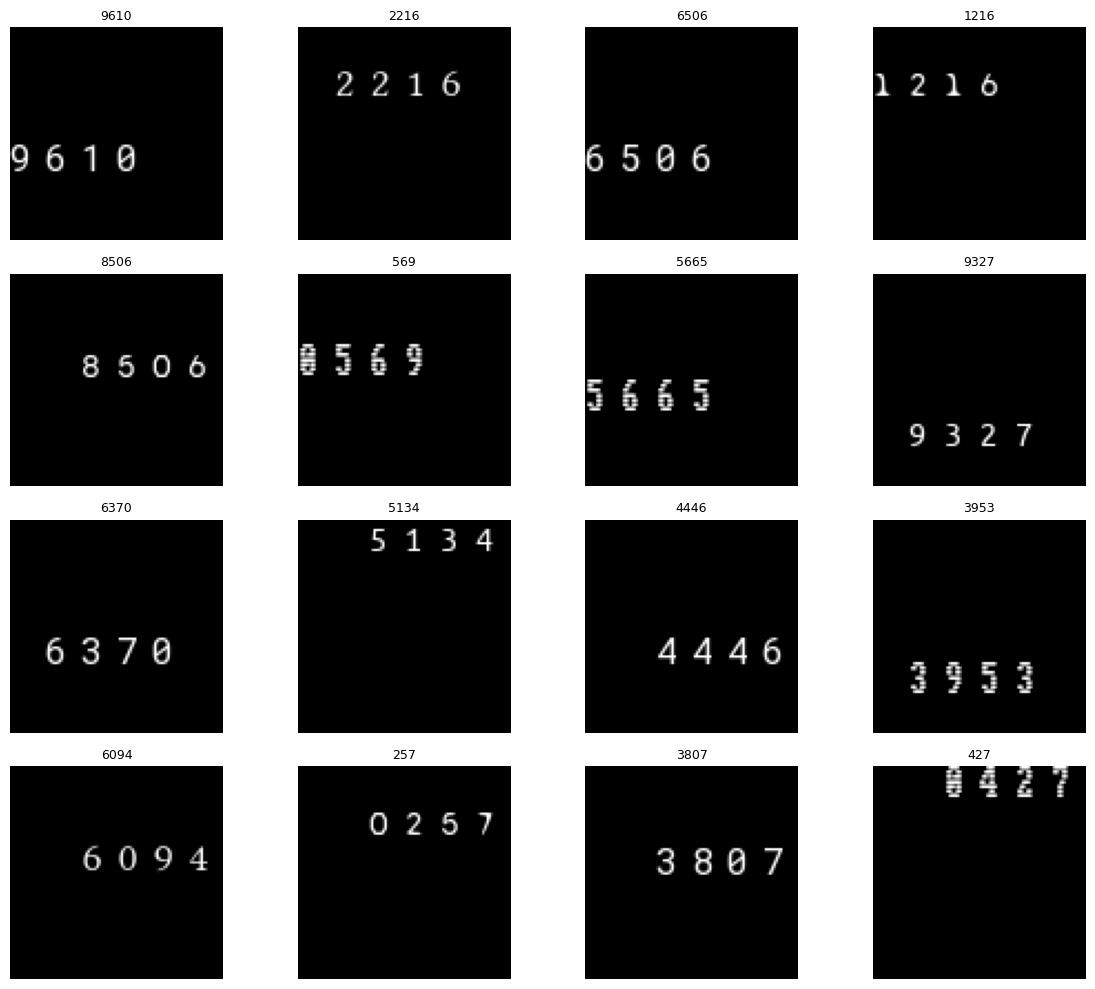


Recommendations:
- Start with safe_baseline, then try object_crop only if preview shows large background.


In [25]:
# ============================================================
# 2. HEALTH CHECK MACHINE
# ============================================================

def image_blur_score(gray):
    if CV2_AVAILABLE:
        return float(cv2.Laplacian(gray, cv2.CV_64F).var())
    gy, gx = np.gradient(gray.astype(float))
    return float(np.var(gx) + np.var(gy))

def run_health_check(n=64):
    step("Step 2/9: Health check")
    train_df = STATE["train_df"]
    assert train_df is not None, "Run Step 1B first."
    n = min(n, len(train_df))
    sample_idx = np.linspace(0, len(train_df) - 1, n).astype(int)
    rows = []
    bad = []
    samples = []
    titles = []
    for idx in sample_idx:
        try:
            img = get_raw_image(train_df, idx)
            h, w = img.shape[:2]
            gray = np.asarray(Image.fromarray(img).convert("L"))
            rows.append({
                "idx": int(idx),
                "h": int(h),
                "w": int(w),
                "aspect": float(w / max(h, 1)),
                "brightness": float(gray.mean()),
                "blur": image_blur_score(gray),
            })
            if len(samples) < PREVIEW_ROWS:
                samples.append(img)
                titles.append(str(train_df.iloc[idx]["_label"]))
        except Exception as e:
            bad.append((idx, repr(e)))

    report = pd.DataFrame(rows)
    label_counts = train_df["_label"].value_counts().to_frame("count")
    label_counts["pct"] = label_counts["count"] / len(train_df)
    imbalance_ratio = float(label_counts["count"].max() / max(label_counts["count"].min(), 1)) if len(label_counts) else 1.0
    small_images = bool(len(report) and report[["h", "w"]].min(axis=1).median() <= 64)
    aspect_varies = bool(len(report) and report["aspect"].std() > 0.35)

    STATE["health"] = {
        "bad_count": len(bad),
        "imbalance_ratio": imbalance_ratio,
        "small_images": small_images,
        "aspect_varies": aspect_varies,
        "is_csv_pixels": LOADER_MODE == "csv_pixels",
    }

    print("[OK]" if not bad else "[WARN]", f"bad/corrupt sampled images: {len(bad)} / {n}")
    print("[WARN]" if imbalance_ratio >= 3 else "[OK]", f"class imbalance ratio: {imbalance_ratio:.2f}x")
    print("[WARN]" if aspect_varies else "[OK]", f"aspect ratio varies: {aspect_varies}")
    print("[INFO]", f"small images or csv_pixels: {small_images or LOADER_MODE == 'csv_pixels'}")
    if bad[:5]:
        print("Bad examples:", bad[:5])

    print("\nLabel distribution:")
    display(label_counts)
    print("\nImage health summary:")
    display(report.describe().T if len(report) else report)
    show_grid(samples, titles=titles, n=PREVIEW_ROWS, figsize=(12, 10))

    print("\nRecommendations:")
    if imbalance_ratio >= 3:
        print("- EVAL_BLOCK = 'macro_f1_eval' or 'balanced_accuracy_eval'; LOSS_BLOCK = 'weighted_ce'")
    if LOADER_MODE == "csv_pixels" or small_images:
        print("- SEGMENT_BLOCK = 'none' (segmentation usually hurts small/csv pixel images)")
    if aspect_varies:
        print("- PREPROCESS_BLOCK = 'resize_pad_rgb' to preserve aspect ratio")
    print("- Start with safe_baseline, then try object_crop only if preview shows large background.")

run_health_check()

## 3A. Parameter: Segmentation

In [26]:
# ============================================================
# 3A. SEGMENTATION PARAMETERS
# ============================================================

describe_options("Available SEGMENT_BLOCK", {
    "none": "use full original image",
    "center_crop": "crop center square at original resolution",
    "contour_crop": "crop largest contour/object at original resolution",
    "threshold_crop": "threshold foreground then crop active area",
    "tile_2x2": "split image into 4 tiles; aggregate predictions later",
    "tile_3x3": "split image into 9 tiles; aggregate predictions later",
})

SEGMENT_BLOCK = "none"
TILE_AGG = "mean_softmax"
SEGMENT_PREVIEW_ROWS = 8


Available SEGMENT_BLOCK
- none: use full original image
- center_crop: crop center square at original resolution
- contour_crop: crop largest contour/object at original resolution
- threshold_crop: threshold foreground then crop active area
- tile_2x2: split image into 4 tiles; aggregate predictions later
- tile_3x3: split image into 9 tiles; aggregate predictions later


## 3B. Mesin: Segmentation Preview


Step 3/9: Segmentation preview on raw images
Current SEGMENT_BLOCK: none
Original samples:


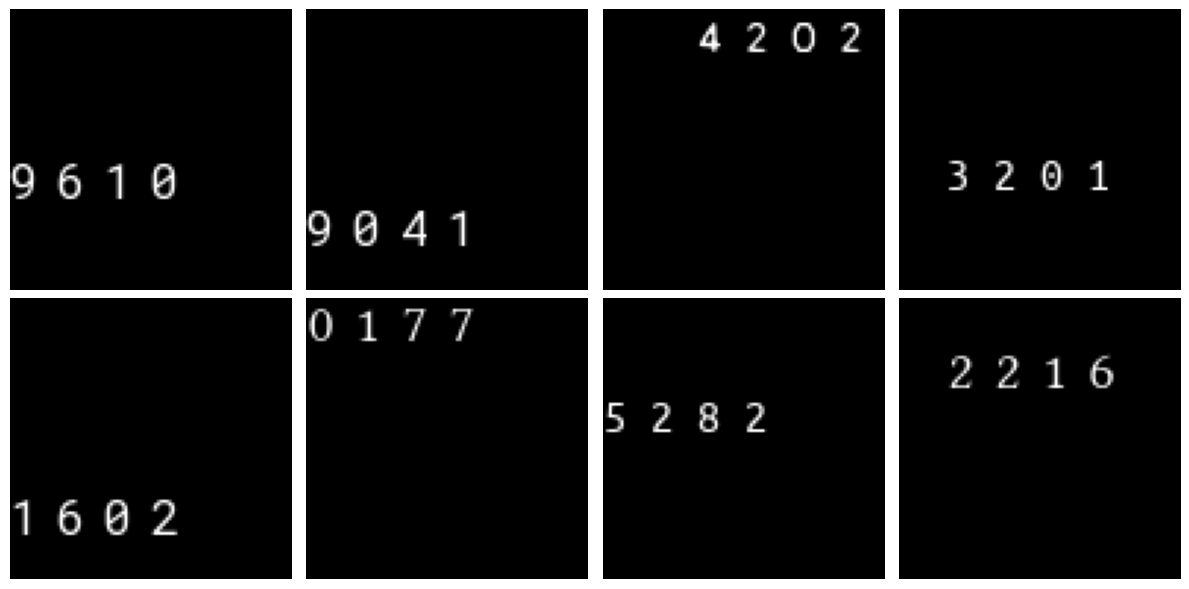

Segment/crop/tile outputs:


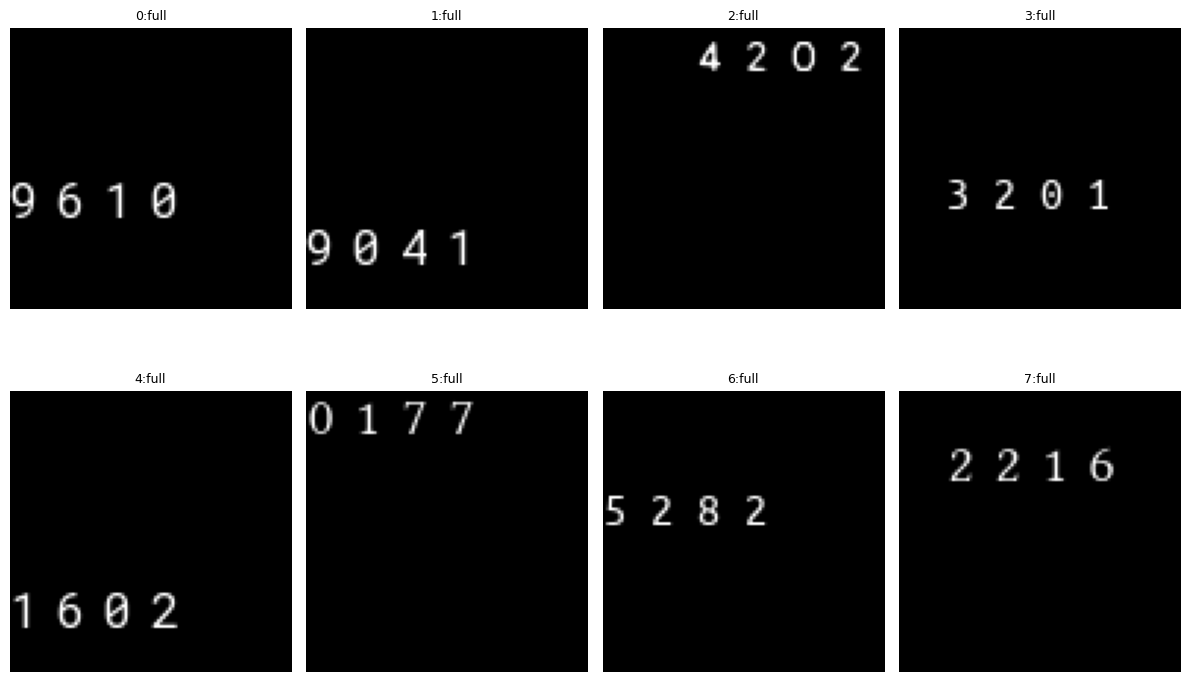

In [27]:
# ============================================================
# 3B. SEGMENTATION MACHINE
# ============================================================

def crop_box_safe(img, x, y, w, h, pad=4):
    H, W = img.shape[:2]
    x0 = max(0, x - pad)
    y0 = max(0, y - pad)
    x1 = min(W, x + w + pad)
    y1 = min(H, y + h + pad)
    if x1 <= x0 or y1 <= y0:
        return img
    return img[y0:y1, x0:x1]

def segment_none(img):
    return [img], ["full"]

def segment_center_crop(img):
    h, w = img.shape[:2]
    side = min(h, w)
    y = (h - side) // 2
    x = (w - side) // 2
    return [img[y:y + side, x:x + side]], ["center"]

def segment_threshold_crop(img):
    gray = np.asarray(Image.fromarray(img).convert("L"))
    if CV2_AVAILABLE:
        blur = cv2.GaussianBlur(gray, (5, 5), 0)
        _, th = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        # choose foreground polarity that is less dominant
        if th.mean() > 127:
            th = 255 - th
        kernel = np.ones((5, 5), np.uint8)
        th = cv2.morphologyEx(th, cv2.MORPH_CLOSE, kernel)
        coords = cv2.findNonZero(th)
        if coords is None:
            return [img], ["fallback_full"]
        x, y, w, h = cv2.boundingRect(coords)
        return [crop_box_safe(img, x, y, w, h)], ["threshold_crop"]
    mask = gray < gray.mean()
    ys, xs = np.where(mask)
    if len(xs) == 0:
        return [img], ["fallback_full"]
    return [crop_box_safe(img, xs.min(), ys.min(), xs.max() - xs.min() + 1, ys.max() - ys.min() + 1)], ["threshold_crop"]

def segment_contour_crop(img):
    if not CV2_AVAILABLE:
        return segment_threshold_crop(img)
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    _, th = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    if th.mean() > 127:
        th = 255 - th
    contours, _ = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return [img], ["fallback_full"]
    cnt = max(contours, key=cv2.contourArea)
    area = cv2.contourArea(cnt)
    if area < 0.01 * img.shape[0] * img.shape[1]:
        return [img], ["fallback_full"]
    x, y, w, h = cv2.boundingRect(cnt)
    return [crop_box_safe(img, x, y, w, h)], ["contour_crop"]

def segment_tile(img, grid):
    h, w = img.shape[:2]
    crops = []
    names = []
    for r in range(grid):
        for c in range(grid):
            y0 = int(round(r * h / grid))
            y1 = int(round((r + 1) * h / grid))
            x0 = int(round(c * w / grid))
            x1 = int(round((c + 1) * w / grid))
            crops.append(img[y0:y1, x0:x1])
            names.append(f"tile_{r}_{c}")
    return crops, names

def apply_segment(img, block=None):
    block = block or SEGMENT_BLOCK
    if block == "none":
        return segment_none(img)
    if block == "center_crop":
        return segment_center_crop(img)
    if block == "contour_crop":
        return segment_contour_crop(img)
    if block == "threshold_crop":
        return segment_threshold_crop(img)
    if block == "tile_2x2":
        return segment_tile(img, 2)
    if block == "tile_3x3":
        return segment_tile(img, 3)
    raise ValueError(f"Unknown SEGMENT_BLOCK: {block}")

def preview_segmentation():
    step("Step 3/9: Segmentation preview on raw images")
    train_df = STATE["train_df"]
    originals = []
    outputs = []
    titles = []
    for i in range(min(SEGMENT_PREVIEW_ROWS, len(train_df))):
        img = get_raw_image(train_df, i)
        crops, names = apply_segment(img)
        originals.append(img)
        outputs.extend(crops[:min(3, len(crops))])
        titles.extend([f"{i}:{name}" for name in names[:min(3, len(crops))]])
    print("Current SEGMENT_BLOCK:", SEGMENT_BLOCK)
    if SEGMENT_BLOCK.startswith("tile"):
        print("WARNING: tile-inherits-label can add label noise. Validation/test metrics aggregate at original-image level.")
    if LOADER_MODE == "csv_pixels" and SEGMENT_BLOCK != "none":
        print("WARNING: LOADER_MODE='csv_pixels' with SEGMENT_BLOCK='" + SEGMENT_BLOCK + "'.")
        print("         Pixel-CSV images are tiny/clean; segmentation usually hurts. Use SEGMENT_BLOCK='none'.")
    print("Original samples:")
    show_grid(originals, n=min(8, len(originals)), figsize=(12, 6))
    print("Segment/crop/tile outputs:")
    show_grid(outputs, titles=titles, n=min(16, len(outputs)), figsize=(12, 8))

preview_segmentation()

## 4A. Parameter: Preprocessing

In [28]:
# ============================================================
# 4A. PREPROCESSING PARAMETERS
# ============================================================

describe_options("Available PREPROCESS_BLOCK", {
    "resize_rgb": "direct resize to IMG_SIZE",
    "resize_pad_rgb": "preserve aspect ratio and pad to square",
    "grayscale": "convert to grayscale then output 1 channel",
    "clahe_gray": "grayscale + CLAHE contrast enhancement, output 1 channel",
    "threshold_binary": "grayscale + binary threshold, output 1 channel",
})

PREPROCESS_BLOCK = "clahe_gray"
IMG_SIZE = 128
COLOR_MODE = "grayscale"  # "rgb" / "grayscale"; "grayscale" forces 1-channel output
CACHE_DATA = True
CACHE_MAX_ENTRIES = 2  # max processed datasets kept in RAM (prevents OOM)


Available PREPROCESS_BLOCK
- resize_rgb: direct resize to IMG_SIZE
- resize_pad_rgb: preserve aspect ratio and pad to square
- grayscale: convert to grayscale then output 1 channel
- clahe_gray: grayscale + CLAHE contrast enhancement, output 1 channel
- threshold_binary: grayscale + binary threshold, output 1 channel


## 4B. Mesin: Preprocessing Preview + Cache


Step 4/9: Preprocessing preview
Current PREPROCESS_BLOCK: clahe_gray | IMG_SIZE: 96 | FAST_DEBUG: True


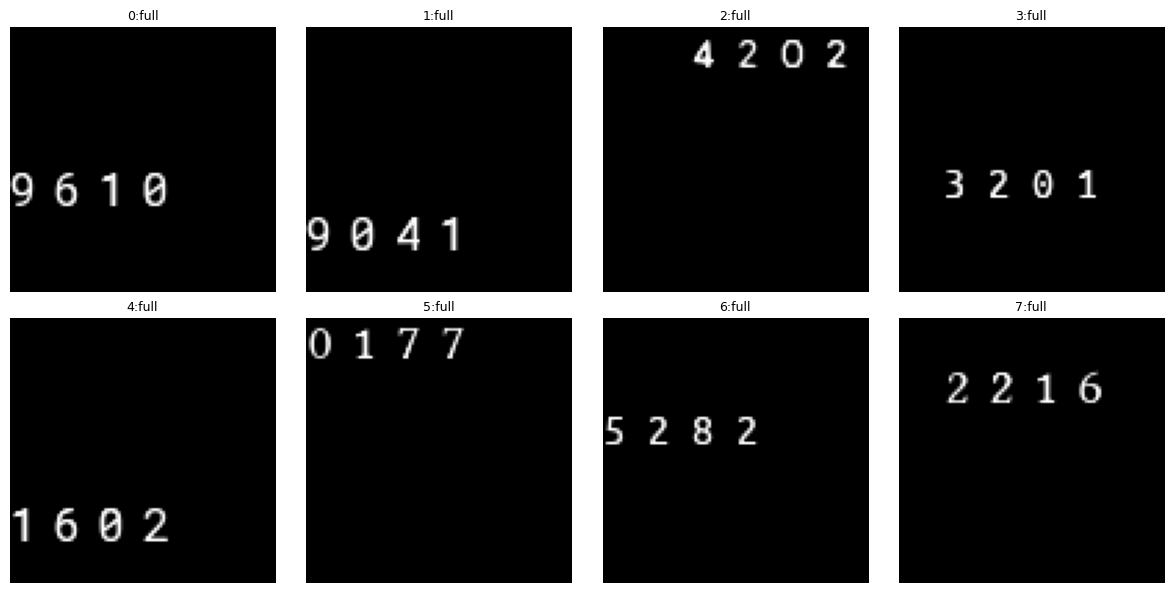


Step 4/9: Building processed cache
Processed train tiles: (500, 96, 96, 1) fallback: 0
Processed test tiles : (500, 96, 96, 1) fallback: 0
num_channels: 1


In [29]:
# ============================================================
# 4B. PREPROCESSING + CACHE MACHINE
# ============================================================

def effective_img_size():
    # FAST_DEBUG forces a small image size for a quick sanity pass.
    return 96 if FAST_DEBUG else IMG_SIZE

def resize_pad_pil(img, size=128, fill=0):
    pil = Image.fromarray(img)
    pil.thumbnail((size, size), Image.Resampling.BILINEAR)
    canvas = Image.new("RGB", (size, size), (fill, fill, fill))
    x = (size - pil.width) // 2
    y = (size - pil.height) // 2
    canvas.paste(pil, (x, y))
    return np.asarray(canvas)

def preprocess_one(img, block=None, size=None):
    block = block or PREPROCESS_BLOCK
    size = size or effective_img_size()
    if img is None or img.size == 0:
        img = np.zeros((size, size, 3), dtype=np.uint8)
    img = np.asarray(Image.fromarray(img).convert("RGB"))

    if block == "resize_rgb":
        out = np.asarray(Image.fromarray(img).resize((size, size), Image.Resampling.BILINEAR))
        channels = 3
    elif block == "resize_pad_rgb":
        out = resize_pad_pil(img, size=size)
        channels = 3
    elif block == "grayscale":
        gray = Image.fromarray(img).convert("L").resize((size, size), Image.Resampling.BILINEAR)
        out = np.asarray(gray)[..., None]
        channels = 1
    elif block == "clahe_gray":
        gray = np.asarray(Image.fromarray(img).convert("L"))
        if CV2_AVAILABLE:
            clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
            gray = clahe.apply(gray)
        gray = Image.fromarray(gray).resize((size, size), Image.Resampling.BILINEAR)
        out = np.asarray(gray)[..., None]
        channels = 1
    elif block == "threshold_binary":
        gray = np.asarray(Image.fromarray(img).convert("L"))
        if CV2_AVAILABLE:
            _, th = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        else:
            th = (gray > gray.mean()).astype(np.uint8) * 255
        th = Image.fromarray(th).resize((size, size), Image.Resampling.NEAREST)
        out = np.asarray(th)[..., None]
        channels = 1
    else:
        raise ValueError(f"Unknown PREPROCESS_BLOCK: {block}")
    out = out.astype(np.uint8)
    # COLOR_MODE override: force 1-channel grayscale when requested
    if COLOR_MODE == "grayscale" and channels == 3:
        out = np.asarray(Image.fromarray(out).convert("L"))[..., None]
        channels = 1
    return out, channels

def current_cache_key():
    payload = {
        "loader": LOADER_MODE,
        "image_col": IMAGE_COL,
        "label_col": LABEL_COL,
        "id_col": ID_COL,
        "image_root": IMAGE_ROOT,
        "pixel_shape": str(PIXEL_SHAPE),
        "segment": SEGMENT_BLOCK,
        "tile_agg": TILE_AGG,
        "preprocess": PREPROCESS_BLOCK,
        "img_size": effective_img_size(),
        "color_mode": COLOR_MODE,
    }
    s = json.dumps(payload, sort_keys=True, default=str)
    return hashlib.md5(s.encode("utf-8")).hexdigest()

def build_processed_split(df, is_train=True):
    X = []
    y = []
    orig = []
    tile_name = []
    ids = []
    fallback_count = 0
    for i in range(len(df)):
        try:
            raw = get_raw_image(df, i)
            crops, names = apply_segment(raw)
        except Exception:
            raw = np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
            crops, names = [raw], ["fallback_error"]
            fallback_count += 1
        for crop, name in zip(crops, names):
            if crop is None or crop.size == 0:
                crop = raw
                name = "fallback_empty"
                fallback_count += 1
            proc, channels = preprocess_one(crop)
            X.append(proc)
            if is_train:
                y.append(int(df.iloc[i]["_label_encoded"]))
            orig.append(int(df.iloc[i]["_orig_index"]))
            tile_name.append(name)
            ids.append(df.iloc[i]["_id"])
    X = np.stack(X).astype(np.uint8)
    y = np.asarray(y, dtype=np.int64) if is_train else None
    return {
        "X": X,
        "y": y,
        "orig_index": np.asarray(orig, dtype=np.int64),
        "tile_name": np.asarray(tile_name),
        "ids": np.asarray(ids),
        "fallback_count": fallback_count,
        "num_channels": int(channels),
    }

def get_processed_data(force=False):
    key = current_cache_key()
    if CACHE_DATA and (not force) and key in STATE["data_cache"]:
        print("Using cached processed data:", key)
        return STATE["data_cache"][key]
    step("Step 4/9: Building processed cache")
    train_pack = build_processed_split(STATE["train_df"], is_train=True)
    test_pack = build_processed_split(STATE["test_df"], is_train=False)
    pack = {"train": train_pack, "test": test_pack, "key": key}
    STATE["num_channels"] = train_pack["num_channels"]
    if CACHE_DATA:
        STATE["data_cache"][key] = pack
        # keep RAM bounded: evict oldest entries beyond CACHE_MAX_ENTRIES
        while len(STATE["data_cache"]) > max(1, CACHE_MAX_ENTRIES):
            oldest = next(iter(STATE["data_cache"]))
            if oldest == key:
                break
            del STATE["data_cache"][oldest]
        gc.collect()
    print("Processed train tiles:", train_pack["X"].shape, "fallback:", train_pack["fallback_count"])
    print("Processed test tiles :", test_pack["X"].shape, "fallback:", test_pack["fallback_count"])
    print("num_channels:", STATE["num_channels"])
    return pack

def preview_preprocessing():
    step("Step 4/9: Preprocessing preview")
    df = STATE["train_df"]
    outputs = []
    titles = []
    for i in range(min(8, len(df))):
        raw = get_raw_image(df, i)
        crops, names = apply_segment(raw)
        proc, _ = preprocess_one(crops[0])
        outputs.append(proc.squeeze() if proc.shape[-1] == 1 else proc)
        titles.append(f"{i}:{names[0]}")
    print("Current PREPROCESS_BLOCK:", PREPROCESS_BLOCK, "| IMG_SIZE:", effective_img_size(), "| FAST_DEBUG:", FAST_DEBUG)
    show_grid(outputs, titles=titles, n=len(outputs), figsize=(12, 6), cmap="gray")
    return get_processed_data(force=False)

DATA_PACK = preview_preprocessing()

## 5A. Parameter: Augmentation

In [30]:
# ============================================================
# 5A. AUGMENTATION PARAMETERS
# ============================================================

describe_options("Available AUGMENT_BLOCK", {
    "no_aug": "debug only",
    "light_aug": "small rotation/shift/brightness, safe default",
    "medium_aug": "stronger rotation/shift/brightness/contrast",
    "safe_document_aug": "small rotation/brightness, no flips",
})

AUGMENT_BLOCK = "light_aug"


Available AUGMENT_BLOCK
- no_aug: debug only
- light_aug: small rotation/shift/brightness, safe default
- medium_aug: stronger rotation/shift/brightness/contrast
- safe_document_aug: small rotation/brightness, no flips


## 5B. Mesin: Augmentation Preview


Step 5/9: Augmentation preview
Using cached processed data: e00da9ab1e7777820b2eaa82abb10d68
Current AUGMENT_BLOCK: light_aug


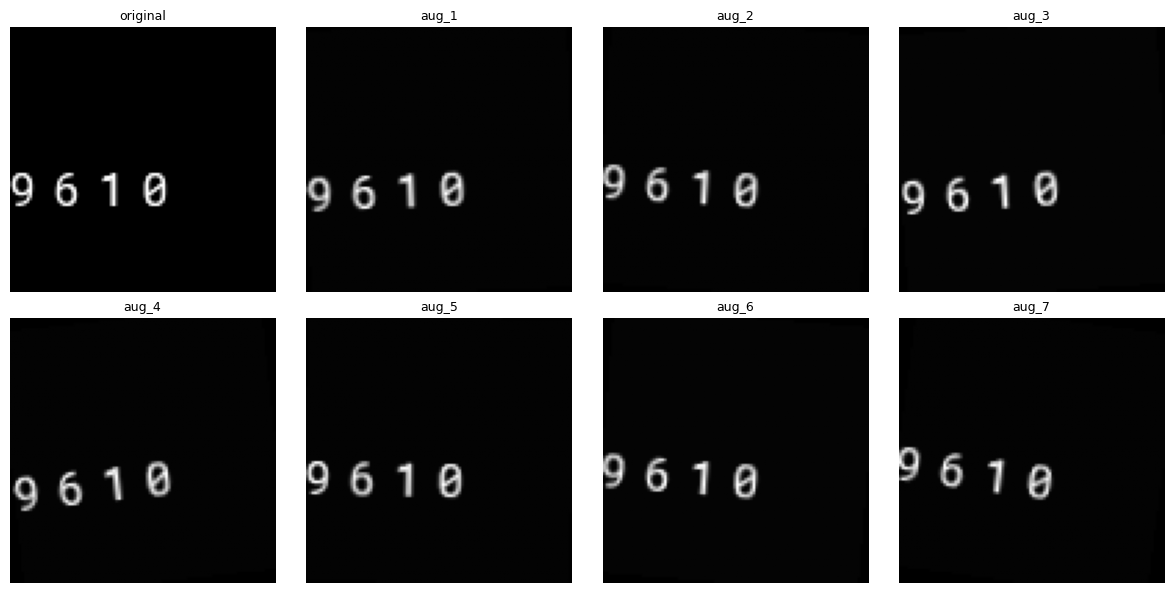

In [31]:
# ============================================================
# 5B. AUGMENTATION MACHINE
# ============================================================

def augment_np(img, block=None):
    block = block or AUGMENT_BLOCK
    arr = img
    if block == "no_aug":
        return arr

    squeeze = False
    if arr.ndim == 3 and arr.shape[-1] == 1:
        arr = arr[..., 0]
        mode = "L"
        squeeze = True
    else:
        mode = "RGB"
    pil = Image.fromarray(arr.astype(np.uint8), mode=mode)

    if block in ["light_aug", "medium_aug", "safe_document_aug"]:
        max_rot = 8 if block != "medium_aug" else 15
        angle = random.uniform(-max_rot, max_rot)
        pil = pil.rotate(angle, resample=Image.Resampling.BILINEAR, fillcolor=0)
        if block == "medium_aug" and random.random() < 0.5:
            pil = ImageOps.mirror(pil)
        brightness = 0.85 + random.random() * (0.30 if block != "medium_aug" else 0.50)
        pil = ImageEnhance.Brightness(pil).enhance(brightness)
        if block == "medium_aug":
            contrast = 0.80 + random.random() * 0.50
            pil = ImageEnhance.Contrast(pil).enhance(contrast)
    else:
        raise ValueError(f"Unknown AUGMENT_BLOCK: {block}")

    out = np.asarray(pil)
    if squeeze:
        out = out[..., None]
    return out.astype(np.uint8)

def preview_augmentation():
    step("Step 5/9: Augmentation preview")
    pack = get_processed_data()
    X = pack["train"]["X"]
    base = X[0]
    imgs = [base.squeeze() if base.shape[-1] == 1 else base]
    titles = ["original"]
    for i in range(7):
        aug = augment_np(base)
        imgs.append(aug.squeeze() if aug.shape[-1] == 1 else aug)
        titles.append(f"aug_{i+1}")
    print("Current AUGMENT_BLOCK:", AUGMENT_BLOCK)
    if AUGMENT_BLOCK == "no_aug":
        print("WARNING: no_aug is for debug only. From-scratch CNN usually needs augmentation.")
    show_grid(imgs, titles=titles, n=len(imgs), figsize=(12, 6), cmap="gray")

preview_augmentation()

## 6A. Parameter: Model

In [32]:
# ============================================================
# 6A. MODEL PARAMETERS
# ============================================================

describe_options("Available MODEL_BLOCK", {
    "tiny_cnn": "debug model, very fast",
    "small_cnn": "main model: Conv + BatchNorm + ReLU + Pool + Dropout",
    "residual_small": "optional stronger model after baseline",
})

MODEL_BLOCK = "small_cnn"


Available MODEL_BLOCK
- tiny_cnn: debug model, very fast
- small_cnn: main model: Conv + BatchNorm + ReLU + Pool + Dropout
- residual_small: optional stronger model after baseline


## 6B. Mesin: Build Model

In [33]:
# ============================================================
# 6B. MODEL BUILD MACHINE
# ============================================================

if TORCH_AVAILABLE:
    class TinyCNN(nn.Module):
        def __init__(self, in_channels, num_classes):
            super().__init__()
            self.net = nn.Sequential(
                nn.Conv2d(in_channels, 16, 3, padding=1),
                nn.BatchNorm2d(16),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
                nn.Conv2d(16, 32, 3, padding=1),
                nn.BatchNorm2d(32),
                nn.ReLU(inplace=True),
                nn.AdaptiveAvgPool2d(1),
                nn.Flatten(),
                nn.Dropout(0.20),
                nn.Linear(32, num_classes),
            )
        def forward(self, x):
            return self.net(x)

    class SmallCNN(nn.Module):
        def __init__(self, in_channels, num_classes):
            super().__init__()
            self.features = nn.Sequential(
                nn.Conv2d(in_channels, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
                nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True),
                nn.MaxPool2d(2), nn.Dropout2d(0.05),
                nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
                nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
                nn.MaxPool2d(2), nn.Dropout2d(0.10),
                nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
                nn.MaxPool2d(2), nn.Dropout2d(0.15),
                nn.AdaptiveAvgPool2d(1),
            )
            self.head = nn.Sequential(nn.Flatten(), nn.Dropout(0.35), nn.Linear(128, num_classes))
        def forward(self, x):
            return self.head(self.features(x))

    class ResidualBlock(nn.Module):
        def __init__(self, channels):
            super().__init__()
            self.block = nn.Sequential(
                nn.Conv2d(channels, channels, 3, padding=1), nn.BatchNorm2d(channels), nn.ReLU(inplace=True),
                nn.Conv2d(channels, channels, 3, padding=1), nn.BatchNorm2d(channels),
            )
        def forward(self, x):
            return F.relu(x + self.block(x), inplace=True)

    class ResidualSmall(nn.Module):
        def __init__(self, in_channels, num_classes):
            super().__init__()
            self.stem = nn.Sequential(nn.Conv2d(in_channels, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(inplace=True))
            self.net = nn.Sequential(
                ResidualBlock(32), nn.MaxPool2d(2),
                nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(inplace=True),
                ResidualBlock(64), nn.MaxPool2d(2),
                nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
                ResidualBlock(128), nn.AdaptiveAvgPool2d(1),
                nn.Flatten(), nn.Dropout(0.35), nn.Linear(128, num_classes),
            )
        def forward(self, x):
            return self.net(self.stem(x))

def build_model(block=None):
    assert TORCH_AVAILABLE, "PyTorch is required for model build/training."
    block = block or MODEL_BLOCK
    in_channels = int(STATE["num_channels"] or 3)
    num_classes = int(STATE["num_classes"])
    if block == "tiny_cnn":
        model = TinyCNN(in_channels, num_classes)
    elif block == "small_cnn":
        model = SmallCNN(in_channels, num_classes)
    elif block == "residual_small":
        model = ResidualSmall(in_channels, num_classes)
    else:
        raise ValueError(f"Unknown MODEL_BLOCK: {block}")
    return model

def build_current_model():
    step("Step 6/9: Build model")
    model = build_model()
    STATE["model"] = model
    print("MODEL_BLOCK:", MODEL_BLOCK)
    print("input channels:", STATE["num_channels"], "| output classes:", STATE["num_classes"])
    print(model)
    return model

if TORCH_AVAILABLE:
    build_current_model()
else:
    print("Skipping local model build because PyTorch is unavailable.")


Step 6/9: Build model
MODEL_BLOCK: small_cnn
input channels: 1 | output classes: 500
SmallCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.05, inplace=False)
    (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (13): 

## 7A. Parameter: Training & Validation

In [34]:
# ============================================================
# 7A. TRAINING PARAMETERS
# ============================================================

EPOCHS = 15
BATCH_SIZE = 32
LEARNING_RATE = 1e-3
VALIDATION_MODE = "stratified_holdout"
VAL_SIZE = 0.2
LOSS_BLOCK = "ce"  # auto / ce / weighted_ce / focal
LR_SCHEDULE = "cosine"  # cosine / step_lr / none
USE_AMP = True
EARLY_STOPPING_PATIENCE = 5
EVAL_BLOCK = "accuracy_eval"  # accuracy_eval / macro_f1_eval / balanced_accuracy_eval
RUN_TAG = "baseline"

SEGMENT_BLOCK = 'none'
PREPROCESS_BLOCK = 'clahe_gray'
IMG_SIZE = 128
COLOR_MODE = 'grayscale'
AUGMENT_BLOCK = 'light_aug'
MODEL_BLOCK = 'small_cnn'
EVAL_BLOCK = 'accuracy_eval'
LOSS_BLOCK = 'ce'

## 7B. Mesin: Train + Validate

In [35]:
# Quick hack — drop singletons sebelum split
vc = STATE["train_df"]["_label"].value_counts()
keep = vc[vc >= 2].index
STATE["train_df"] = STATE["train_df"][STATE["train_df"]["_label"].isin(keep)].reset_index(drop=True)
# rebuild label encoder
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
STATE["train_df"]["_label_encoded"] = le.fit_transform(STATE["train_df"]["_label"].astype(str))
STATE["label_encoder"] = le
STATE["classes"] = list(le.classes_)
STATE["num_classes"] = len(le.classes_)
STATE["data_cache"] = {}  # invalidate cache
print("After filter:", len(STATE["train_df"]), "rows,", STATE["num_classes"], "classes")

After filter: 0 rows, 0 classes


In [36]:
import pandas as pd
DATA_ROOT = "/kaggle/input/competitions/seleksi-gemastik-2026-problem-2/data"
# atau ganti ke "/kaggle/input/competitions/..." kalau itu yang lo pake

train_df = pd.read_csv(f"{DATA_ROOT}/train.csv")
sample_df = pd.read_csv(f"{DATA_ROOT}/sample_submission.csv")

print("=== TRAIN ===")
print("Columns:", train_df.columns.tolist())
print("Shape:", train_df.shape)
print(train_df.head(5))

print("\n=== SAMPLE SUBMISSION ===")
print("Columns:", sample_df.columns.tolist())
print("Shape:", sample_df.shape)
print(sample_df.head(5))

print("\n=== OVERLAP ===")
print("Train image_id sample:", train_df["image_id"].head(3).tolist())
print("Sample image_id sample:", sample_df["image_id"].head(3).tolist())
if "image_pair" in train_df.columns:
    print("train has image_pair:", train_df["image_pair"].head(3).tolist())

=== TRAIN ===
Columns: ['image_id', 'char']
Shape: (500, 2)
  image_id  char
0  id_30U7  9610
1  id_5OK6  9041
2  id_EKC8  4202
3  id_GYIW  3201
4  id_213Y  1602

=== SAMPLE SUBMISSION ===
Columns: ['image_id', 'image_pair']
Shape: (500, 2)
  image_id image_pair
0  id_DCBL    id_AAAA
1  id_YUKN    id_AAAA
2  id_25WM    id_AAAA
3  id_6ESM    id_AAAA
4  id_L51F    id_AAAA

=== OVERLAP ===
Train image_id sample: ['id_30U7', 'id_5OK6', 'id_EKC8']
Sample image_id sample: ['id_DCBL', 'id_YUKN', 'id_25WM']


In [37]:
# ============================================================
# 7B. TRAINING MACHINE
# ============================================================

class ArrayTileDataset(Dataset):
    def __init__(self, X, y=None, orig_index=None, train=False):
        self.X = X
        self.y = y
        self.orig_index = orig_index
        self.train = train
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        img = self.X[idx]
        if self.train:
            img = augment_np(img)
        arr = img.astype(np.float32) / 255.0
        if arr.ndim == 2:
            arr = arr[..., None]
        arr = np.transpose(arr, (2, 0, 1))
        x = torch.tensor(arr, dtype=torch.float32)
        orig = int(self.orig_index[idx]) if self.orig_index is not None else int(idx)
        if self.y is None:
            return x, orig
        return x, torch.tensor(int(self.y[idx]), dtype=torch.long), orig

class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0):
        super().__init__()
        self.weight = weight
        self.gamma = gamma
    def forward(self, logits, targets):
        ce = F.cross_entropy(logits, targets, weight=self.weight, reduction="none")
        pt = torch.exp(-ce)
        loss = ((1 - pt) ** self.gamma) * ce
        return loss.mean()

def metric_value(y_true, y_pred, metric):
    if metric == "accuracy_eval":
        return accuracy_score(y_true, y_pred)
    if metric == "macro_f1_eval":
        return f1_score(y_true, y_pred, average="macro", zero_division=0)
    if metric == "balanced_accuracy_eval":
        return balanced_accuracy_score(y_true, y_pred)
    raise ValueError(f"Unknown EVAL_BLOCK: {metric}")

def choose_loss(y_train):
    counts = np.bincount(y_train, minlength=STATE["num_classes"])
    imbalance = counts.max() / max(counts[counts > 0].min(), 1)
    block = LOSS_BLOCK
    if block == "auto":
        block = "weighted_ce" if imbalance >= 3 or EVAL_BLOCK in ["macro_f1_eval", "balanced_accuracy_eval"] else "ce"
    weight = None
    if block in ["weighted_ce", "focal"]:
        inv = counts.sum() / np.maximum(counts, 1)
        inv = inv / inv.mean()
        weight = torch.tensor(inv, dtype=torch.float32, device=DEVICE)
    if block == "ce":
        return nn.CrossEntropyLoss(), block
    if block == "weighted_ce":
        return nn.CrossEntropyLoss(weight=weight), block
    if block == "focal":
        return FocalLoss(weight=weight), block
    raise ValueError(f"Unknown LOSS_BLOCK: {LOSS_BLOCK}")

def aggregate_probs(probs, orig_indices):
    grouped = defaultdict(list)
    for p, oid in zip(probs, orig_indices):
        grouped[int(oid)].append(p)
    out_ids = sorted(grouped)
    out_probs = np.stack([np.mean(grouped[i], axis=0) for i in out_ids])
    return np.asarray(out_ids), out_probs

def predict_loader_probs(model, loader):
    model.eval()
    probs = []
    origs = []
    with torch.no_grad():
        for batch in loader:
            if len(batch) == 3:
                xb, _, oid = batch
            else:
                xb, oid = batch
            xb = xb.to(DEVICE)
            logits = model(xb)
            p = torch.softmax(logits, dim=1).detach().cpu().numpy()
            probs.append(p)
            origs.extend(np.asarray(oid).tolist())
    return np.vstack(probs), np.asarray(origs)

def make_original_split(pack):
    train_df = STATE["train_df"]
    orig_ids = train_df["_orig_index"].to_numpy()
    orig_y = train_df["_label_encoded"].to_numpy()
    if VALIDATION_MODE != "stratified_holdout":
        raise ValueError("Only stratified_holdout is implemented as default. Add k-fold manually if needed.")
    tr_orig, va_orig = train_test_split(
        orig_ids,
        test_size=VAL_SIZE,
        random_state=SEED,
        stratify=orig_y,
    )
    tr_orig = set(map(int, tr_orig))
    va_orig = set(map(int, va_orig))
    tile_orig = pack["train"]["orig_index"]
    train_mask = np.asarray([int(o) in tr_orig for o in tile_orig])
    val_mask = np.asarray([int(o) in va_orig for o in tile_orig])
    return train_mask, val_mask, orig_y

def train_current_model(overrides=None):
    assert TORCH_AVAILABLE, "PyTorch is required for training. Use Kaggle runtime with PyTorch."
    seed_everything(SEED)
    overrides = overrides or {}

    effective_epochs = int(overrides.get("EPOCHS", EPOCHS))
    effective_batch = int(overrides.get("BATCH_SIZE", BATCH_SIZE))
    effective_lr = float(overrides.get("LEARNING_RATE", LEARNING_RATE))
    effective_model_block = overrides.get("MODEL_BLOCK", MODEL_BLOCK)
    effective_tag = overrides.get("RUN_TAG", RUN_TAG)
    if FAST_DEBUG:
        effective_epochs = min(effective_epochs, 2)
        effective_model_block = "tiny_cnn"

    t0 = time.time()
    pack = get_processed_data()
    train_mask, val_mask, orig_y_all = make_original_split(pack)
    X = pack["train"]["X"]
    y = pack["train"]["y"]
    orig = pack["train"]["orig_index"]

    train_ds = ArrayTileDataset(X[train_mask], y[train_mask], orig[train_mask], train=True)
    val_ds = ArrayTileDataset(X[val_mask], y[val_mask], orig[val_mask], train=False)
    train_loader = DataLoader(train_ds, batch_size=effective_batch, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_ds, batch_size=effective_batch, shuffle=False, num_workers=0)

    model = build_model(effective_model_block).to(DEVICE)
    criterion, used_loss = choose_loss(y[train_mask])
    optimizer = torch.optim.AdamW(model.parameters(), lr=effective_lr, weight_decay=1e-4)
    if LR_SCHEDULE == "cosine":
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(1, effective_epochs))
    elif LR_SCHEDULE == "step_lr":
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=max(1, effective_epochs // 3), gamma=0.5)
    else:
        scheduler = None

    scaler = torch.amp.GradScaler("cuda", enabled=bool(USE_AMP and DEVICE == "cuda"))
    best_score = -1
    best_state = None
    best_epoch = 0
    patience_left = EARLY_STOPPING_PATIENCE
    history = []

    val_orig_true = {int(i): int(y) for i, y in zip(STATE["train_df"]["_orig_index"], STATE["train_df"]["_label_encoded"])}

    step(f"Step 7/9: Training {effective_tag}")
    print("model:", effective_model_block, "| epochs:", effective_epochs, "| batch:", effective_batch, "| lr:", effective_lr)
    print("loss:", used_loss, "| eval:", EVAL_BLOCK, "| FAST_DEBUG:", FAST_DEBUG)

    for epoch in range(1, effective_epochs + 1):
        model.train()
        total_loss = 0.0
        total_n = 0
        for xb, yb, _ in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=bool(USE_AMP and DEVICE == "cuda")):
                logits = model(xb)
                loss = criterion(logits, yb)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            total_loss += float(loss.item()) * len(xb)
            total_n += len(xb)
        if scheduler is not None:
            scheduler.step()

        probs, val_tile_orig = predict_loader_probs(model, val_loader)
        val_orig_ids, val_probs = aggregate_probs(probs, val_tile_orig)
        val_pred = val_probs.argmax(axis=1)
        val_true = np.asarray([val_orig_true[int(i)] for i in val_orig_ids])
        val_score = metric_value(val_true, val_pred, EVAL_BLOCK)
        train_loss = total_loss / max(total_n, 1)
        history.append({"epoch": epoch, "train_loss": train_loss, "val_score": val_score})
        print(f"epoch={epoch:03d} train_loss={train_loss:.5f} val_{EVAL_BLOCK}={val_score:.5f}")

        if val_score > best_score:
            best_score = float(val_score)
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            patience_left = EARLY_STOPPING_PATIENCE
        else:
            patience_left -= 1
            if patience_left <= 0:
                print("Early stopping.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    seconds = time.time() - t0

    STATE["model"] = model
    if STATE["best_score"] is None or best_score > STATE["best_score"]:
        STATE["best_score"] = best_score
        STATE["best_model"] = copy.deepcopy(model).cpu()
        STATE["best_run"] = effective_tag
        STATE["best_config"] = {
            "SEGMENT_BLOCK": SEGMENT_BLOCK,
            "PREPROCESS_BLOCK": PREPROCESS_BLOCK,
            "IMG_SIZE": effective_img_size(),
            "COLOR_MODE": COLOR_MODE,
            "TILE_AGG": TILE_AGG,
            "MODEL_BLOCK": effective_model_block,
        }

    run = {
        "tag": effective_tag,
        "loader": LOADER_MODE,
        "segment": SEGMENT_BLOCK,
        "preprocess": PREPROCESS_BLOCK,
        "augment": AUGMENT_BLOCK,
        "model": effective_model_block,
        "img_size": effective_img_size(),
        "metric": EVAL_BLOCK,
        "val_score": best_score,
        "epochs_ran": best_epoch,
        "seconds": round(seconds, 1),
        "cache_key": pack["key"],
    }
    STATE["runs"].append(run)
    runs_df = pd.DataFrame(STATE["runs"]).sort_values("val_score", ascending=False)
    display(runs_df)

    hist = pd.DataFrame(history)
    if len(hist):
        plt.figure(figsize=(10, 4))
        plt.plot(hist["epoch"], hist["train_loss"], label="train_loss")
        plt.title("Training loss")
        plt.legend()
        plt.show()
        plt.figure(figsize=(10, 4))
        plt.plot(hist["epoch"], hist["val_score"], label=f"val_{EVAL_BLOCK}")
        plt.title("Validation score")
        plt.legend()
        plt.show()
    return model

if TORCH_AVAILABLE:
    train_current_model()
else:
    print("Skipping training because PyTorch is unavailable in this local runtime.")


Step 4/9: Building processed cache


ValueError: need at least one array to stack

## 8A. Parameter: Submission

In [ ]:
# ============================================================
# 8A. SUBMISSION PARAMETERS
# ============================================================

SUBMISSION_FILE = "submission_debug.csv" if FAST_DEBUG else "submission.csv"
SUBMISSION_TARGET_COL = None  # None -> second column of sample_submission or "label"

## 8B. Mesin: Predict + Save Submission

In [ ]:
# ============================================================
# 8B. SUBMISSION MACHINE
# ============================================================

def predict_test_with_model(model):
    assert TORCH_AVAILABLE, "PyTorch is required for prediction."
    pack = get_processed_data()
    X = pack["test"]["X"]
    orig = pack["test"]["orig_index"]
    ids = pack["test"]["ids"]
    ds = ArrayTileDataset(X, y=None, orig_index=orig, train=False)
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    model = model.to(DEVICE)
    probs, tile_orig = predict_loader_probs(model, loader)
    orig_ids, orig_probs = aggregate_probs(probs, tile_orig)
    pred_encoded = orig_probs.argmax(axis=1)
    pred_labels = STATE["label_encoder"].inverse_transform(pred_encoded)

    # Map original-index order back to test row order.
    pred_by_orig = {int(o): p for o, p in zip(orig_ids, pred_labels)}
    ordered = [pred_by_orig[int(o)] for o in STATE["test_df"]["_orig_index"]]
    return np.asarray(ordered)

def validate_and_save_submission(preds, filename=None):
    filename = filename or SUBMISSION_FILE
    sample = STATE["sample_submission"]
    test_df = STATE["test_df"]
    preds = np.asarray(preds)
    if len(preds) != len(test_df):
        raise ValueError(f"Prediction count {len(preds)} != test rows {len(test_df)}")

    # predictions are in test_df row order -> key them by test id
    test_ids = test_df["_id"].astype(str).tolist()
    pred_by_id = dict(zip(test_ids, preds))

    if sample is not None:
        sub = sample.copy()
        id_col = sub.columns[0]
        target_col = SUBMISSION_TARGET_COL or (sub.columns[1] if len(sub.columns) >= 2 else "label")
        sample_ids = sub[id_col].astype(str)

        # primary: join by exact id
        mapped = sample_ids.map(pred_by_id)
        # retry: match by filename stem (handles extension differences)
        if mapped.isna().any():
            pred_by_stem = {}
            for tid, p in zip(test_ids, preds):
                pred_by_stem.setdefault(Path(tid).stem, p)
            retry = sample_ids.map(lambda s: pred_by_stem.get(Path(str(s)).stem))
            mapped = mapped.where(mapped.notna(), retry)
        # fail hard: an unverifiable id match must NOT be saved as a guess
        if mapped.isna().any():
            n_missing = int(mapped.isna().sum())
            raise ValueError(
                f"{n_missing} sample_submission id(s) could not be matched to a prediction "
                f"by id or by filename stem. Set ID_COL correctly in Step 1A and rerun. "
                f"Submission NOT saved."
            )
        sub[target_col] = np.asarray(mapped)
    else:
        target_col = SUBMISSION_TARGET_COL or "label"
        sub = pd.DataFrame({"id": test_ids, target_col: preds})

    if sub.isna().any().any():
        raise ValueError("Submission contains NaN.")
    if sample is not None and list(sub.columns) != list(sample.columns):
        raise ValueError("Submission columns changed. Expected same columns as sample_submission.")
    sub.to_csv(filename, index=False)
    print("Saved:", filename, "| rows:", len(sub), "| target column:", target_col)
    display(sub.head())
    print("Prediction distribution:")
    display(pd.Series(sub[target_col]).value_counts().sort_index().to_frame("count"))
    return sub

def make_submission():
    step("Step 8/9: Submission")
    assert STATE["best_model"] is not None, "No best model yet. Run Step 7B first."
    global SEGMENT_BLOCK, PREPROCESS_BLOCK, IMG_SIZE, COLOR_MODE, TILE_AGG
    cfg = STATE.get("best_config")
    if cfg:
        # the best model was trained on a specific config -> predict with THAT config
        saved = (SEGMENT_BLOCK, PREPROCESS_BLOCK, IMG_SIZE, COLOR_MODE, TILE_AGG)
        SEGMENT_BLOCK = cfg["SEGMENT_BLOCK"]
        PREPROCESS_BLOCK = cfg["PREPROCESS_BLOCK"]
        IMG_SIZE = cfg["IMG_SIZE"]
        COLOR_MODE = cfg["COLOR_MODE"]
        TILE_AGG = cfg["TILE_AGG"]
        print("Submission rebuilds test data with best_model config:", cfg)
        try:
            preds = predict_test_with_model(STATE["best_model"])
        finally:
            SEGMENT_BLOCK, PREPROCESS_BLOCK, IMG_SIZE, COLOR_MODE, TILE_AGG = saved
    else:
        preds = predict_test_with_model(STATE["best_model"])
    return validate_and_save_submission(preds)

if TORCH_AVAILABLE and STATE.get("best_model") is not None:
    make_submission()
else:
    print("Skipping submission because no trained model is available in this runtime.")

## 9A. Parameter: Experiment Queue

In [ ]:
# ============================================================
# 9A. EXPERIMENT QUEUE PARAMETERS
# ============================================================

RUN_QUEUE = False
EXPERIMENT_QUEUE = [
    {"tag": "baseline"},
    {"tag": "crop", "SEGMENT_BLOCK": "contour_crop"},
    {"tag": "bigger", "IMG_SIZE": 160, "MODEL_BLOCK": "residual_small", "EPOCHS": 20},
]

## 9B. Mesin: Run Experiment Queue

In [ ]:
# ============================================================
# 9B. EXPERIMENT QUEUE MACHINE
# ============================================================

def run_experiment_queue():
    if not RUN_QUEUE:
        print("RUN_QUEUE is False. Set RUN_QUEUE=True to run queued experiments.")
        return
    assert TORCH_AVAILABLE, "PyTorch is required for experiment queue."
    global SEGMENT_BLOCK, PREPROCESS_BLOCK, IMG_SIZE, COLOR_MODE, AUGMENT_BLOCK, MODEL_BLOCK, EPOCHS, RUN_TAG

    base = {
        "SEGMENT_BLOCK": SEGMENT_BLOCK,
        "PREPROCESS_BLOCK": PREPROCESS_BLOCK,
        "IMG_SIZE": IMG_SIZE,
        "COLOR_MODE": COLOR_MODE,
        "AUGMENT_BLOCK": AUGMENT_BLOCK,
        "MODEL_BLOCK": MODEL_BLOCK,
        "EPOCHS": EPOCHS,
        "RUN_TAG": RUN_TAG,
    }
    for item in EXPERIMENT_QUEUE:
        print("\n" + "#" * 100)
        print("Running queue item:", item)
        print("#" * 100)
        SEGMENT_BLOCK = item.get("SEGMENT_BLOCK", base["SEGMENT_BLOCK"])
        PREPROCESS_BLOCK = item.get("PREPROCESS_BLOCK", base["PREPROCESS_BLOCK"])
        IMG_SIZE = item.get("IMG_SIZE", base["IMG_SIZE"])
        COLOR_MODE = item.get("COLOR_MODE", base["COLOR_MODE"])
        AUGMENT_BLOCK = item.get("AUGMENT_BLOCK", base["AUGMENT_BLOCK"])
        MODEL_BLOCK = item.get("MODEL_BLOCK", base["MODEL_BLOCK"])
        EPOCHS = item.get("EPOCHS", base["EPOCHS"])
        RUN_TAG = item.get("tag", item.get("RUN_TAG", base["RUN_TAG"]))
        get_processed_data(force=False)
        train_current_model()

    # restore visible params
    SEGMENT_BLOCK = base["SEGMENT_BLOCK"]
    PREPROCESS_BLOCK = base["PREPROCESS_BLOCK"]
    IMG_SIZE = base["IMG_SIZE"]
    COLOR_MODE = base["COLOR_MODE"]
    AUGMENT_BLOCK = base["AUGMENT_BLOCK"]
    MODEL_BLOCK = base["MODEL_BLOCK"]
    EPOCHS = base["EPOCHS"]
    RUN_TAG = base["RUN_TAG"]

    runs_df = pd.DataFrame(STATE["runs"]).sort_values("val_score", ascending=False)
    runs_df.to_csv("cv_experiment_scores.csv", index=False)
    print("Saved: cv_experiment_scores.csv")
    display(runs_df)
    if STATE["best_model"] is not None:
        make_submission()

run_experiment_queue()

## Final Notes

Checklist before real submission:

- `FAST_DEBUG=False`
- metric/loss set according to Kaggle metric
- preview segmentation before training
- run at least `safe_baseline`
- submit early, then experiment
- no pretrained model calls